# 🏥 Projet Machine Learning — Dermatologie
## 📋 Tableau DSO (Division des Sous-Objectifs)

| **Bénéfice Opérationnel (BO)** | **DSO** | **Modèles utilisés** | **Étudiant** |
|---|---|---|---|
| **Analyse et prédiction rapide des maladies** | **Classification supervisée** (Régression logistique) pour prédire la présence de la maladie | Régression Logistique, Naïve Bayes | Étudiant 1 |
| **Recommandation de traitement personnalisé** | **Classification supervisée** (SVM, Arbre de décision) pour prédire le traitement optimal | SVM, Arbre de décision | Étudiant 2 |
| **Optimisation du diagnostic par ensemble** | **Apprentissage d'ensemble (Ensemble Learning)** pour maximiser précision/stabilité | Random Forest, XGBoost | Étudiant 3 |
| **Segmentation des patients par profil pathologique** | **Clustering non supervisé** pour découvrir les groupes de patients similaires | K-Means, DBSCAN | Étudiant 4 |

---


In [54]:
# ==================================================
# 1. IMPORTATION DES BIBLIOTHEQUES
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures, label_binarize
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, silhouette_score, adjusted_rand_score
)

# DSO 1
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# DSO 2
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

# DSO 3
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# DSO 4
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import KNeighborsClassifier

print("Bibliotheques importees avec succes")


Bibliothèques importées avec succès ✅


In [3]:
# ==================================================
# 2. CHARGEMENT DU DATASET
# ==================================================

from google.colab import files

# Upload du fichier CSV
uploaded = files.upload()

# Recuperation automatique du nom du fichier uploade
filename = list(uploaded.keys())[0]
print("Fichier charge :", filename)

# Chargement du dataset
df = pd.read_csv(filename)

# Affichage dimensions
print("Dimensions du dataset :", df.shape)

# Affichage des 5 premieres lignes
df.head()


Saving dermatology_database_1 (1).csv to dermatology_database_1 (1) (1).csv
Dimensions du dataset : (366, 35)


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [4]:
# ==================================================
# 3. INFORMATIONS GÉNÉRALES
# ==================================================

# Informations générales
df.info()

print("\n============================\n")

# Statistiques descriptives
print(df.describe())

print("\n============================\n")

# Vérification des valeurs nulles
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   erythema                             366 non-null    int64 
 1   scaling                              366 non-null    int64 
 2   definite_borders                     366 non-null    int64 
 3   itching                              366 non-null    int64 
 4   koebner_phenomenon                   366 non-null    int64 
 5   polygonal_papules                    366 non-null    int64 
 6   follicular_papules                   366 non-null    int64 
 7   oral_mucosal_involvement             366 non-null    int64 
 8   knee_and_elbow_involvement           366 non-null    int64 
 9   scalp_involvement                    366 non-null    int64 
 10  family_history                       366 non-null    int64 
 11  melanin_incontinence                 366 non-

In [5]:
# ==================================================
# 4. DÉTECTION DES VALEURS MANQUANTES
# ==================================================

# Vérification des colonnes contenant '?'
for col in df.columns:
    if df[col].astype(str).str.contains(r"\?", regex=True).any():
        print(f"La colonne '{col}' contient des '?'")

La colonne 'age' contient des '?'


In [6]:
# ==================================================
# 5. OBJECTIF DU PROJET
# ==================================================

# Variable cible
target = "class"

# Variables explicatives
X = df.drop(columns=[target])

# Variable à prédire
y = df[target]

print("Nombre de variables explicatives :", X.shape[1])
print("Nombre d'observations :", X.shape[0])

print("\nClasses présentes :")
print(y.value_counts().sort_index())

Nombre de variables explicatives : 34
Nombre d'observations : 366

Classes présentes :
class
1    112
2     61
3     72
4     49
5     52
6     20
Name: count, dtype: int64


In [7]:
# ==================================================
# 6. DIVISION DU DATASET PAR MALADIES
# ==================================================

maladies = {}

for maladie in sorted(df["class"].unique()):

    maladies[maladie] = df[df["class"] == maladie]

    print(f"Classe {maladie} :",
          maladies[maladie].shape)

Classe 1 : (112, 35)
Classe 2 : (61, 35)
Classe 3 : (72, 35)
Classe 4 : (49, 35)
Classe 5 : (52, 35)
Classe 6 : (20, 35)


In [8]:
# ==================================================
# 7. NETTOYAGE COMPLET DU DATASET
# ==================================================

# Copie du dataset
df_clean = df.copy()

# Etape 1 : Remplacer TOUS les '?' par NaN (partout)
df_clean = df_clean.replace("?", np.nan)

# Etape 2 : Forcer la conversion numerique sur toutes les colonnes
#           sauf la cible 'class'
for col in df_clean.columns:
    if col != "class":
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Etape 3 : Remplir les NaN numeriques par la mediane de chaque colonne
#           (plus robuste que 0 ou la moyenne)
for col in df_clean.columns:
    if col != "class":
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

print("Valeurs manquantes apres nettoyage :", df_clean.isnull().sum().sum())
print("Types des colonnes :")
print(df_clean.dtypes.value_counts())
print("Nettoyage termine")


erythema                               0
scaling                                0
definite_borders                       0
itching                                0
koebner_phenomenon                     0
polygonal_papules                      0
follicular_papules                     0
oral_mucosal_involvement               0
knee_and_elbow_involvement             0
scalp_involvement                      0
family_history                         0
melanin_incontinence                   0
eosinophils_infiltrate                 0
PNL_infiltrate                         0
fibrosis_papillary_dermis              0
exocytosis                             0
acanthosis                             0
hyperkeratosis                         0
parakeratosis                          0
clubbing_rete_ridges                   0
elongation_rete_ridges                 0
thinning_suprapapillary_epidermis      0
spongiform_pustule                     0
munro_microabcess                      0
focal_hypergranu

In [9]:
# ==================================================
# 8. VERIFICATION APRES NETTOYAGE
# ==================================================

print("Dimensions      :", df_clean.shape)
print("Valeurs nulles  :", df_clean.isnull().sum().sum())
print("Types object    :", (df_clean.dtypes == object).sum(), "(doit etre 0)")
df_clean.describe()


Valeurs manquantes restantes :
0


In [10]:
# ==================================================
# 9. ENCODAGE DE LA VARIABLE CIBLE (class)
# ==================================================

# La colonne 'class' est deja numerique dans ce dataset,
# mais on s'assure qu'elle est bien en int
df_clean["class"] = df_clean["class"].astype(int)

print("Classes presentes :", sorted(df_clean["class"].unique()))
print("Encodage termine")


Encodage terminé ✅


In [11]:
# ==================================================
# 10. STATISTIQUES APRÈS NETTOYAGE
# ==================================================

print(df_clean.describe())

print("\nValeurs manquantes restantes :")
print(df_clean.isnull().sum().sum())

         erythema     scaling  definite_borders     itching  \
count  366.000000  366.000000        366.000000  366.000000   
mean     2.068306    1.795082          1.549180    1.366120   
std      0.664753    0.701527          0.907525    1.138299   
min      0.000000    0.000000          0.000000    0.000000   
25%      2.000000    1.000000          1.000000    0.000000   
50%      2.000000    2.000000          2.000000    1.000000   
75%      2.000000    2.000000          2.000000    2.000000   
max      3.000000    3.000000          3.000000    3.000000   

       koebner_phenomenon  polygonal_papules  follicular_papules  \
count          366.000000         366.000000          366.000000   
mean             0.633880           0.448087            0.166667   
std              0.908016           0.957327            0.570588   
min              0.000000           0.000000            0.000000   
25%              0.000000           0.000000            0.000000   
50%              0.00000

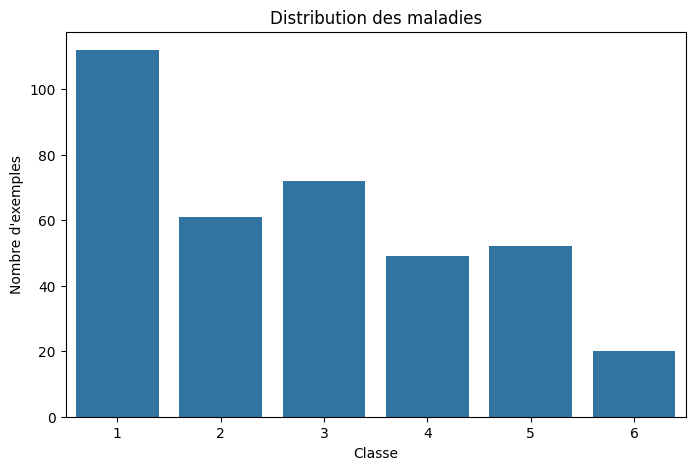

In [12]:
# ==================================================
# 11. VISUALISATION DES CLASSES
# ==================================================

plt.figure(figsize=(8,5))

sns.countplot(x="class", data=df_clean)

plt.title("Distribution des maladies")

plt.xlabel("Classe")

plt.ylabel("Nombre d'exemples")

plt.show()

In [15]:
# ==================================================
# 12. SÉPARATION FEATURES / TARGET
# ==================================================

X = df_clean.drop(columns=["class"])

y = df_clean["class"]

print("Shape X :", X.shape)

print("Shape y :", y.shape)

Shape X : (366, 34)
Shape y : (366,)


In [16]:
# ==================================================
# 13. TRAIN TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)

print("Test :", X_test.shape)

Train : (292, 34)
Test : (74, 34)


In [17]:
# ==================================================
# 14. STANDARDISATION DES VARIABLES
# ==================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Standardisation terminée ✅")

Standardisation terminée ✅


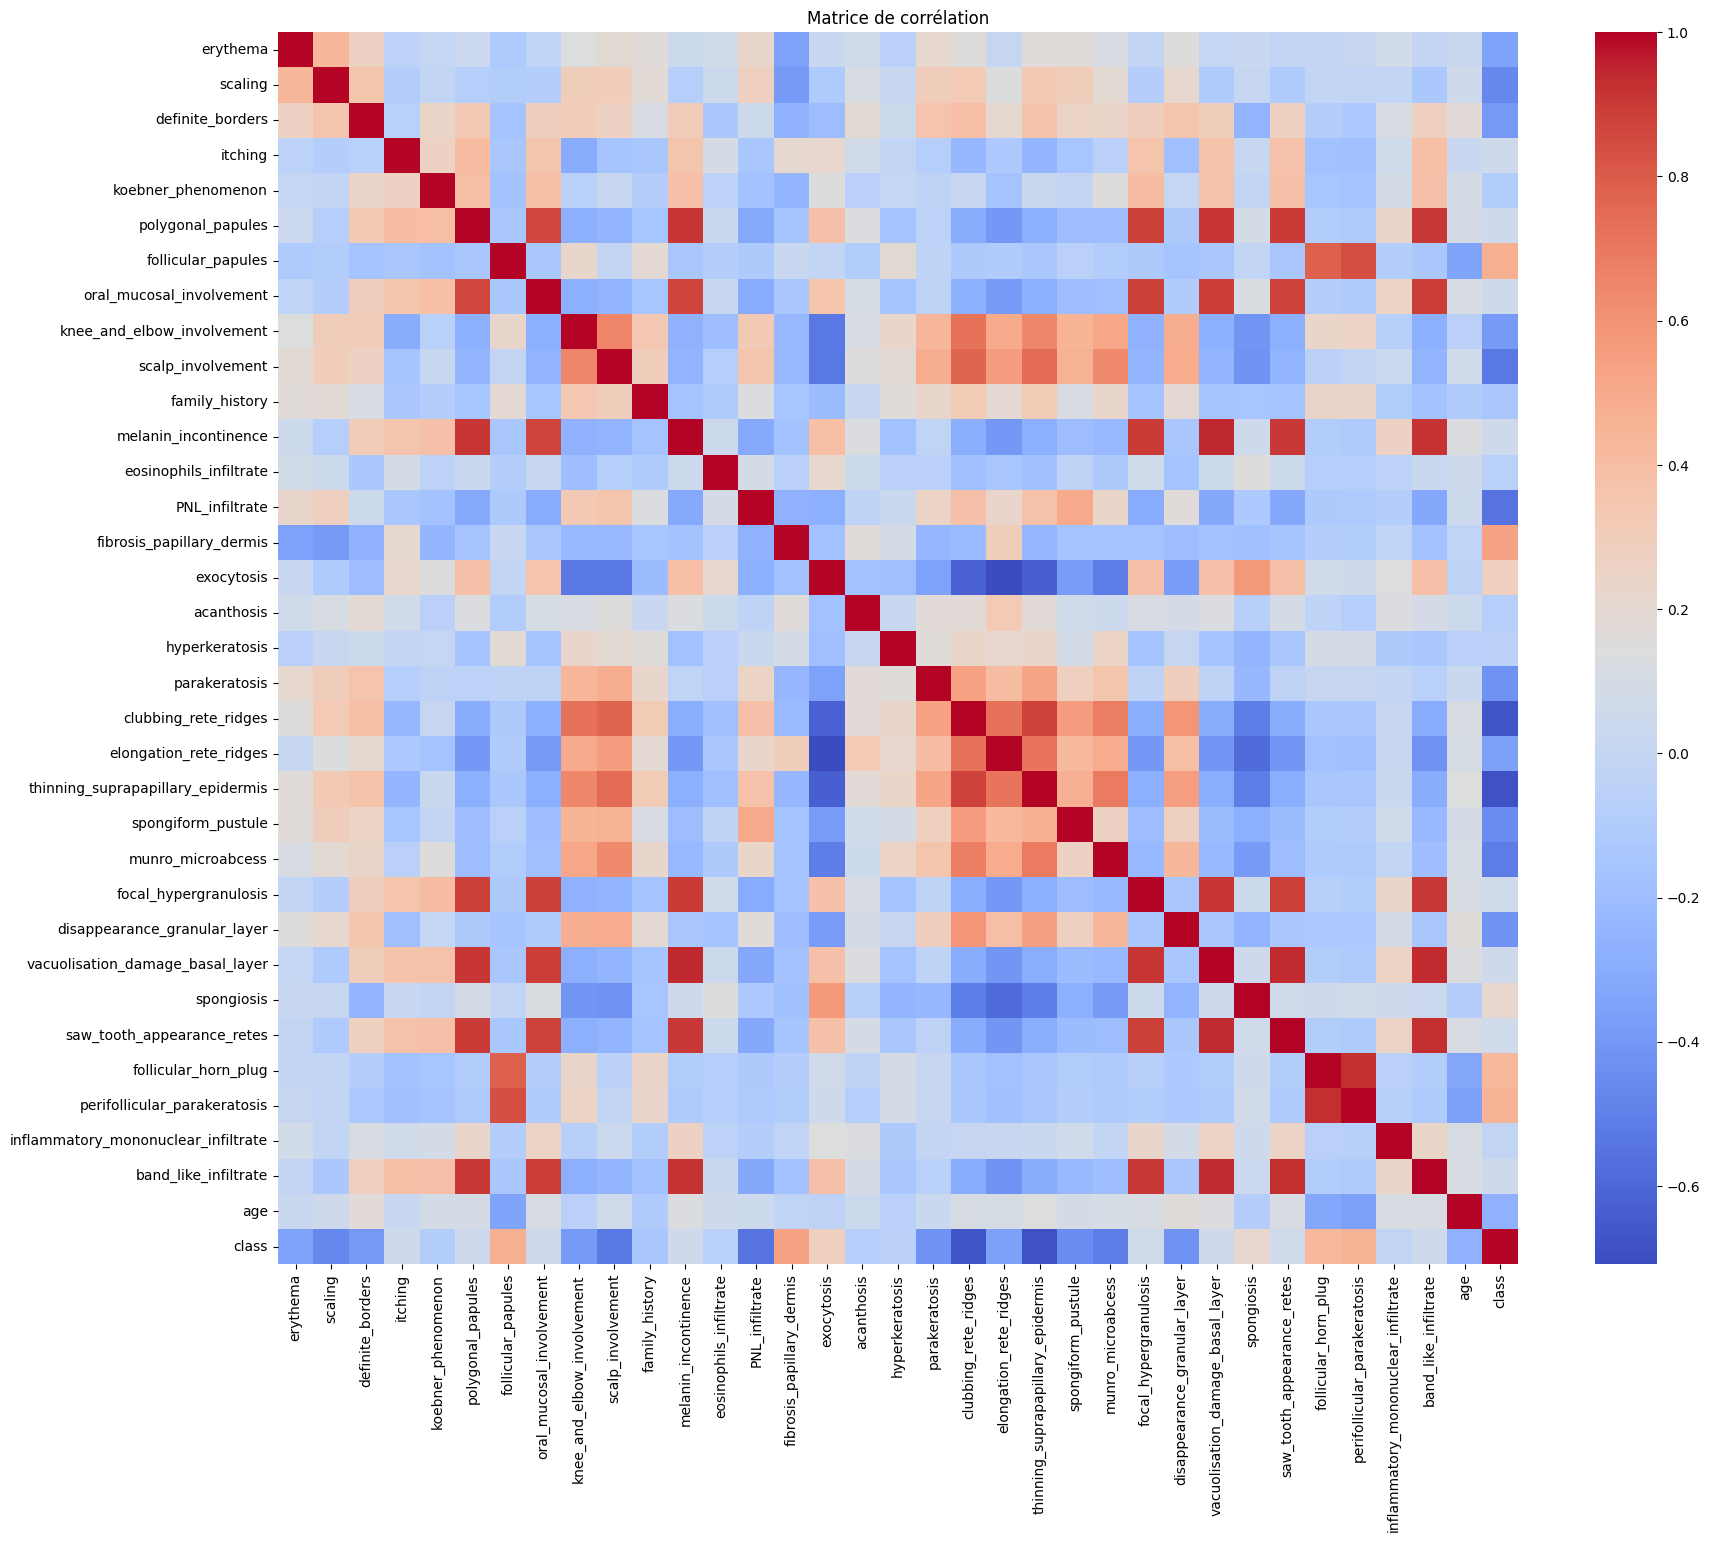

In [18]:
# ==================================================
# 15. MATRICE DE CORRÉLATION
# ==================================================

plt.figure(figsize=(20,16))

correlation_matrix = df_clean.corr()

sns.heatmap(

    correlation_matrix,

    cmap="coolwarm",

    annot=False
)

plt.title("Matrice de corrélation")

plt.show()

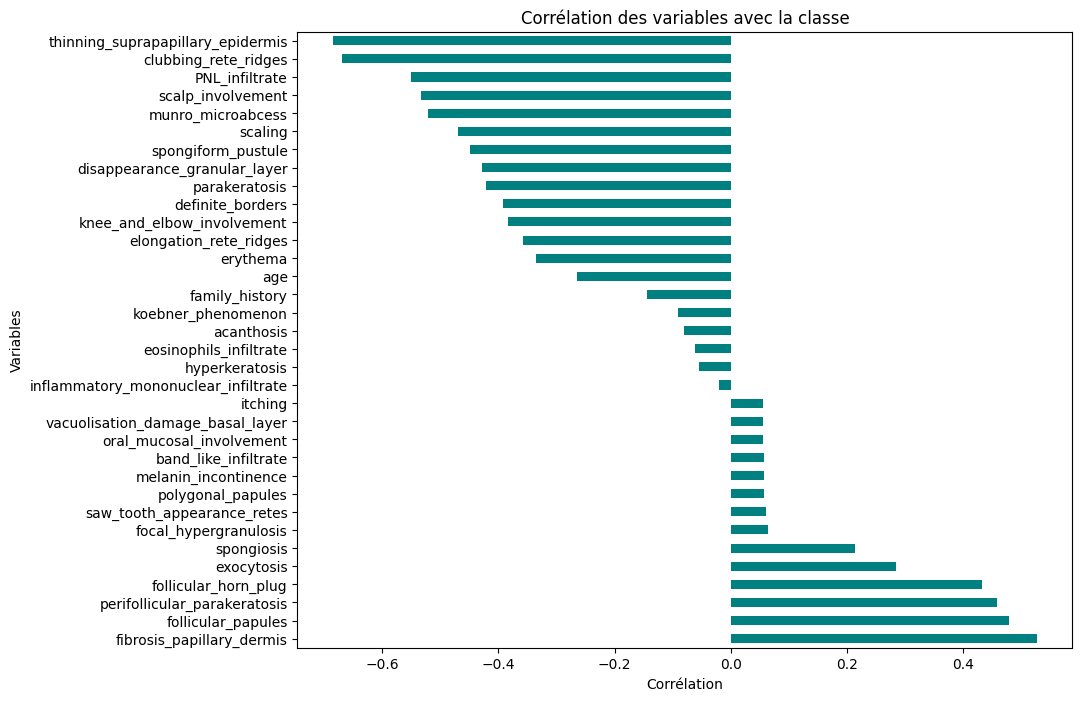

In [19]:
# ==================================================
# 16. CORRÉLATION AVEC LA TARGET
# ==================================================

target_corr = correlation_matrix["class"].sort_values(
    ascending=False
)

plt.figure(figsize=(10,8))

target_corr.drop("class").plot(

    kind="barh",

    color="teal"
)

plt.title("Corrélation des variables avec la classe")

plt.xlabel("Corrélation")

plt.ylabel("Variables")

plt.show()

In [20]:
# ==================================================
# 17. AFFICHAGE DES RELATIONS AVEC LA TARGET
# ==================================================

corr_values = target_corr.drop("class")

# Corrélations fortes positives
print("\n==============================")
print("CORRÉLATIONS FORTES POSITIVES")
print("==============================\n")

strong_positive = corr_values[
    corr_values > 0.5
]

print(
    strong_positive.sort_values(
        ascending=False
    )
)


# Corrélations fortes négatives
print("\n==============================")
print("CORRÉLATIONS FORTES NÉGATIVES")
print("==============================\n")

strong_negative = corr_values[
    corr_values < -0.5
]

print(
    strong_negative.sort_values()
)


# Corrélations moyennes
print("\n==============================")
print("CORRÉLATIONS MOYENNES")
print("==============================\n")

medium_corr = corr_values[
    (abs(corr_values) >= 0.3) &
    (abs(corr_values) <= 0.5)
]

print(
    medium_corr.sort_values(
        ascending=False
    )
)


# Corrélations faibles
print("\n==============================")
print("CORRÉLATIONS FAIBLES")
print("==============================\n")

weak_corr = corr_values[
    abs(corr_values) < 0.3
]

print(
    weak_corr.sort_values(
        ascending=False
    )
)


CORRÉLATIONS FORTES POSITIVES

fibrosis_papillary_dermis    0.526976
Name: class, dtype: float64

CORRÉLATIONS FORTES NÉGATIVES

thinning_suprapapillary_epidermis   -0.684864
clubbing_rete_ridges                -0.668781
PNL_infiltrate                      -0.550195
scalp_involvement                   -0.533208
munro_microabcess                   -0.520995
Name: class, dtype: float64

CORRÉLATIONS MOYENNES

follicular_papules              0.477813
perifollicular_parakeratosis    0.457025
follicular_horn_plug            0.431972
erythema                       -0.335537
elongation_rete_ridges         -0.357924
knee_and_elbow_involvement     -0.383305
definite_borders               -0.391974
parakeratosis                  -0.420742
disappearance_granular_layer   -0.427348
spongiform_pustule             -0.449407
scaling                        -0.468688
Name: class, dtype: float64

CORRÉLATIONS FAIBLES

exocytosis                             0.283433
spongiosis                            

/tmp/ipykernel_2719/1080115706.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


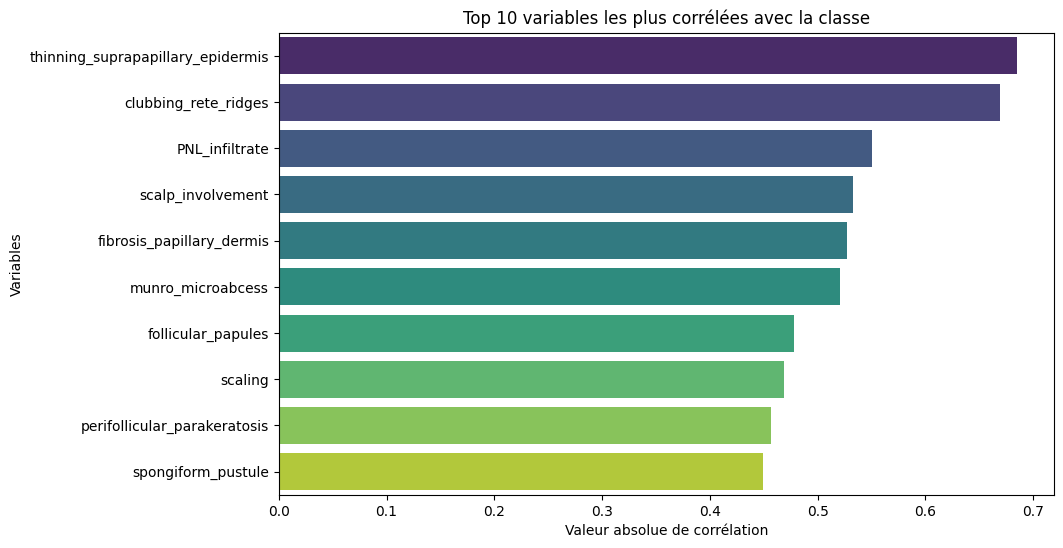

In [21]:
# ==================================================
# 18. TOP VARIABLES LES PLUS CORRÉLÉES
# ==================================================

top_corr = corr_values.abs().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(

    x=top_corr.values,

    y=top_corr.index,

    palette="viridis"
)

plt.title(
    "Top 10 variables les plus corrélées avec la classe"
)

plt.xlabel("Valeur absolue de corrélation")

plt.ylabel("Variables")

plt.show()

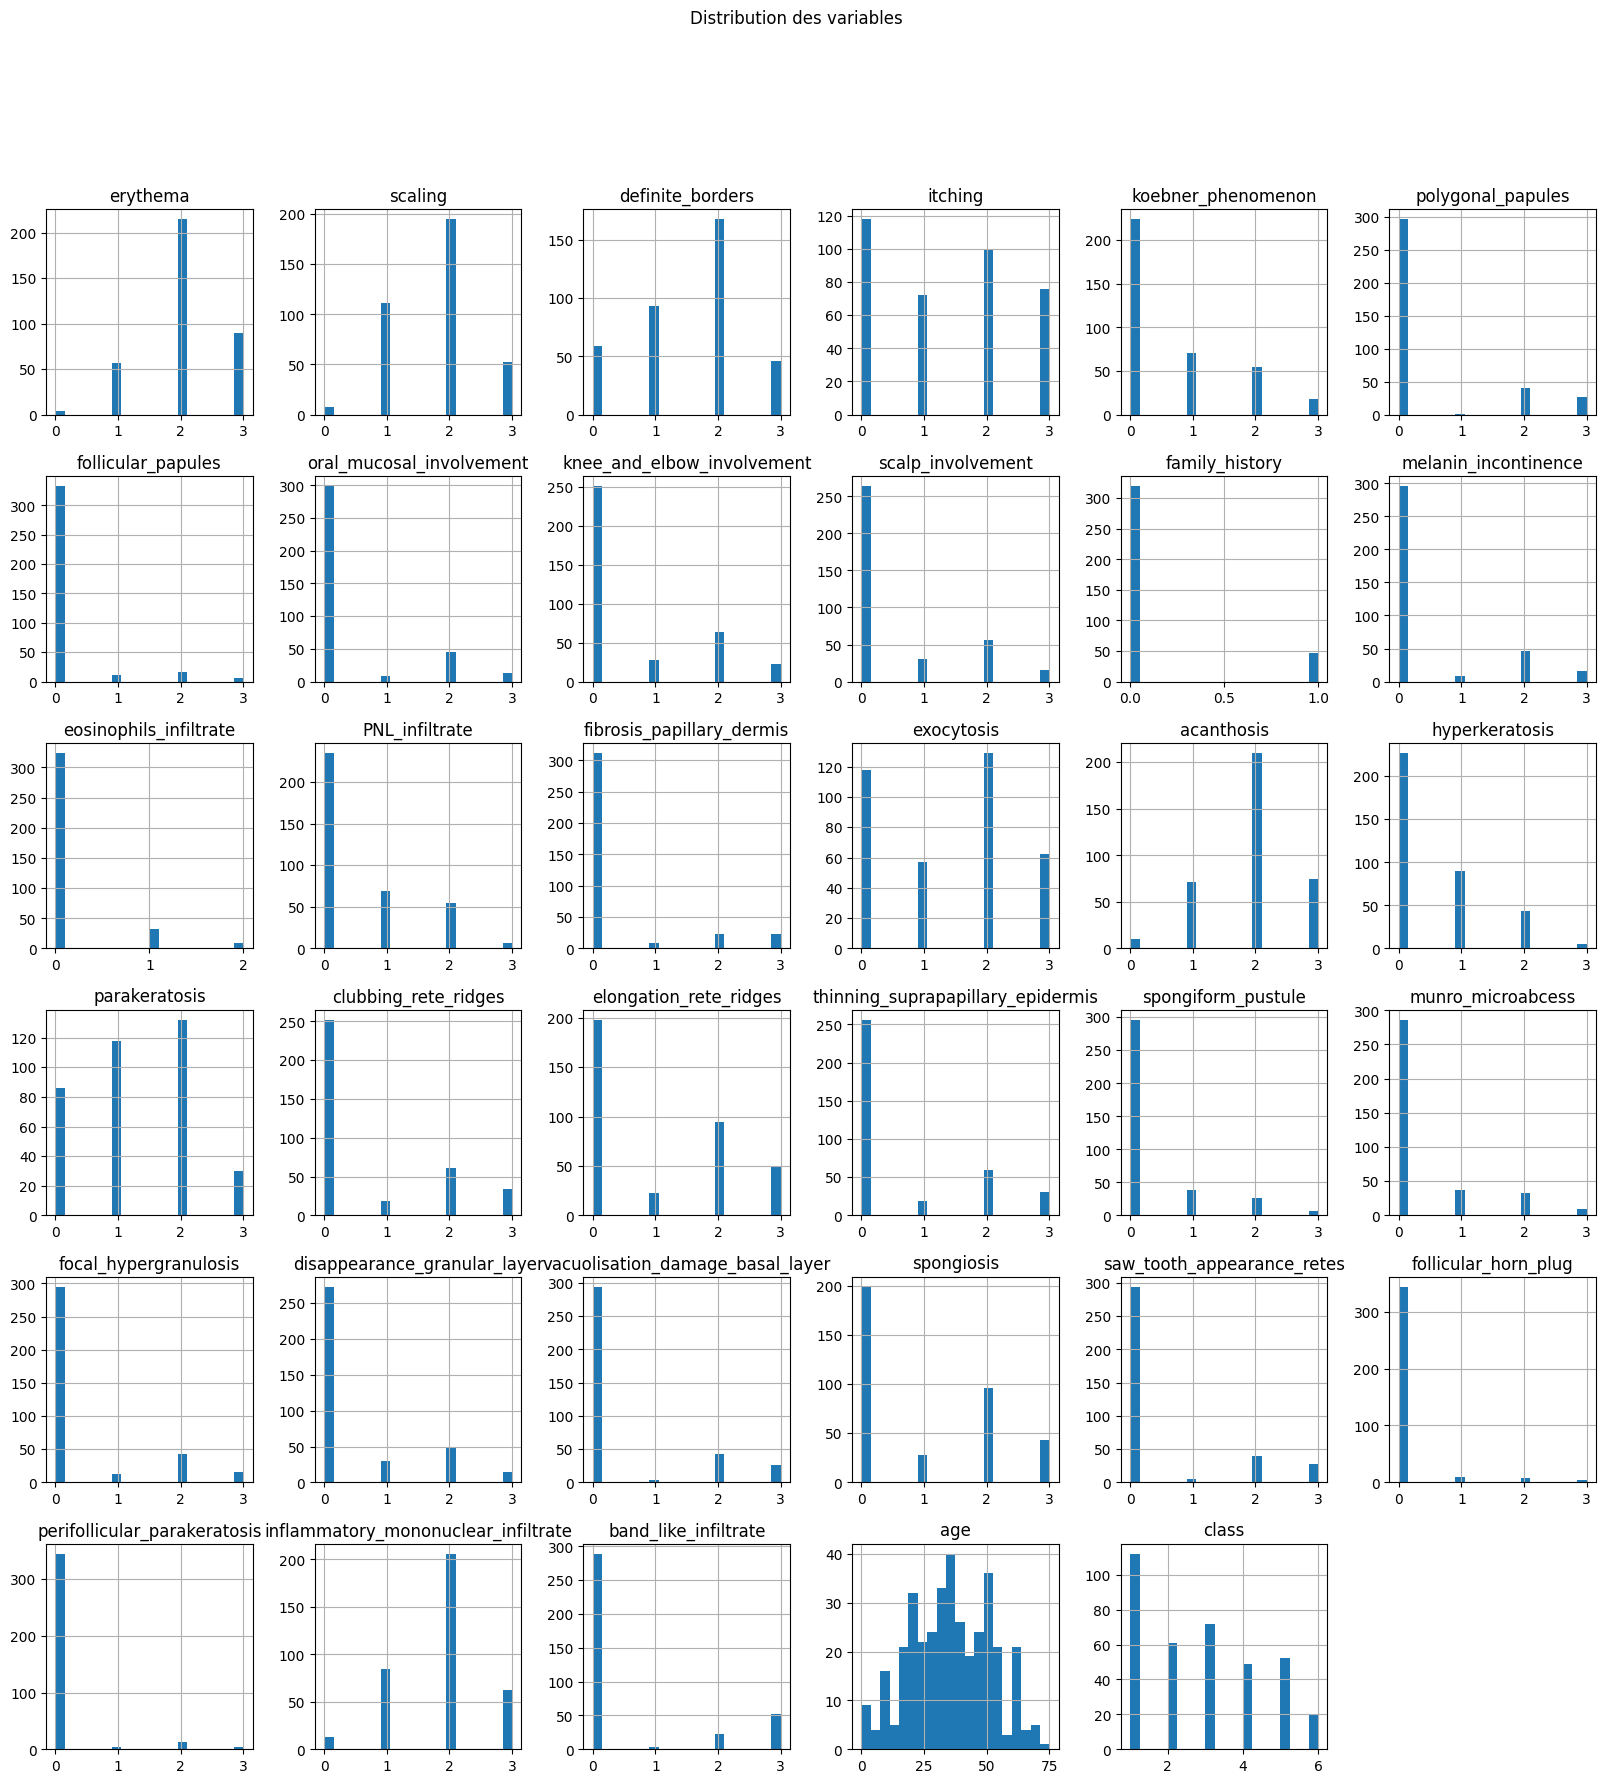

In [22]:
# ==================================================
# 19. DISTRIBUTION DES VARIABLES
# ==================================================

df_clean.hist(
    figsize=(20,20),
    bins=20
)

plt.suptitle("Distribution des variables")

plt.show()

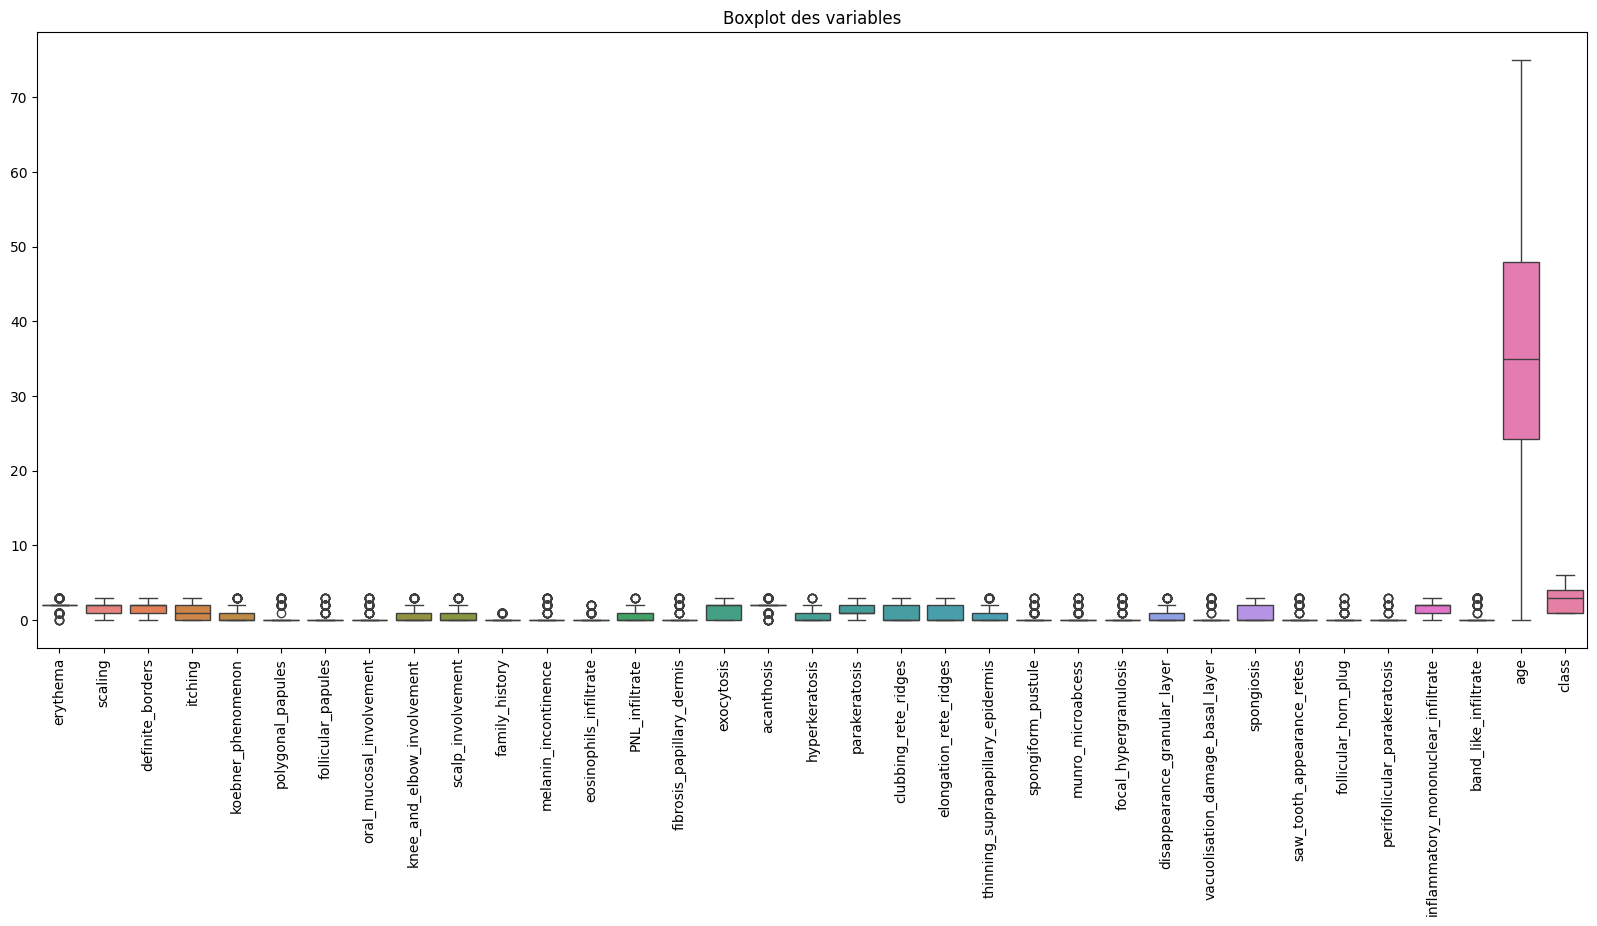

In [23]:
# ==================================================
# 20. BOXPLOT DES VARIABLES
# ==================================================

plt.figure(figsize=(20,8))

sns.boxplot(data=df_clean)

plt.xticks(rotation=90)

plt.title("Boxplot des variables")

plt.show()

In [24]:
# ==================================================
# 21. PCA AVEC 95% DE VARIANCE
# ==================================================

pca_95 = PCA(n_components=0.95)

X_train_pca = pca_95.fit_transform(X_train_scaled)
X_test_pca = pca_95.transform(X_test_scaled)

print("Nombre initial de variables :", X_train_scaled.shape[1])
print("Nombre de composantes PCA gardées :", pca_95.n_components_)
print("Nouvelle forme X_train_pca :", X_train_pca.shape)
print("Nouvelle forme X_test_pca :", X_test_pca.shape)

Nombre initial de variables : 34
Nombre de composantes PCA gardées : 21
Nouvelle forme X_train_pca : (292, 21)
Nouvelle forme X_test_pca : (74, 21)


In [25]:
# ==================================================
# 22. TABLEAU DES COMPOSANTES PCA
# ==================================================

pca_columns = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]

X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_columns)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_columns)

X_train_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21
0,5.119758,2.833576,0.507339,-0.420202,-0.928589,0.267138,-1.190833,0.483156,-1.099741,-0.270436,...,0.256725,1.714462,-0.971828,1.490356,1.007939,0.520951,-0.687311,-0.522811,-0.774601,-0.031258
1,-0.461280,-1.702689,-2.179061,2.791843,1.424274,-0.143216,-0.740341,-0.256190,0.143450,1.926277,...,-0.495478,1.131995,-0.258886,0.091235,0.305479,0.753029,0.044179,-0.006509,-0.661943,0.044769
2,0.395808,-1.353029,-0.252271,-1.242019,-1.034863,-0.161327,-1.366373,-0.552982,-0.955127,-0.981373,...,-0.008535,-0.226440,0.659228,0.163201,-1.517811,-0.506601,-0.169706,-0.271055,-0.197746,0.369268
3,0.622201,-1.887354,-1.047675,-1.501406,-0.776692,1.719479,-0.919575,0.078399,0.857815,-0.510740,...,0.744001,1.132683,0.299534,-0.191719,0.008206,0.065307,-0.161435,0.291630,-0.328671,0.210940
4,0.676166,-2.363152,-0.681273,0.195881,-0.816546,2.048154,-0.169147,1.167641,-0.379277,-0.940745,...,0.979621,-0.980547,-0.387896,0.083081,-0.575487,0.491759,0.675344,-0.183977,-0.294238,0.118561


In [26]:
# ==================================================
# 23. VARIANCE EXPLIQUÉE PCA
# ==================================================

variance_pca = pd.DataFrame({
    "Composante": pca_columns,
    "Variance expliquée": pca_95.explained_variance_ratio_,
    "Variance cumulée": np.cumsum(pca_95.explained_variance_ratio_)
})

variance_pca

,Composante,Variance expliquée,Variance cumulée
0,PC1,0.271429,0.271429
1,PC2,0.162482,0.433911
2,PC3,0.092713,0.526624
3,PC4,0.068651,0.595275
4,PC5,0.038789,0.634064
5,PC6,0.034344,0.668408
6,PC7,0.031409,0.699817
7,PC8,0.028504,0.728322
8,PC9,0.026398,0.754719
9,PC10,0.025071,0.779790


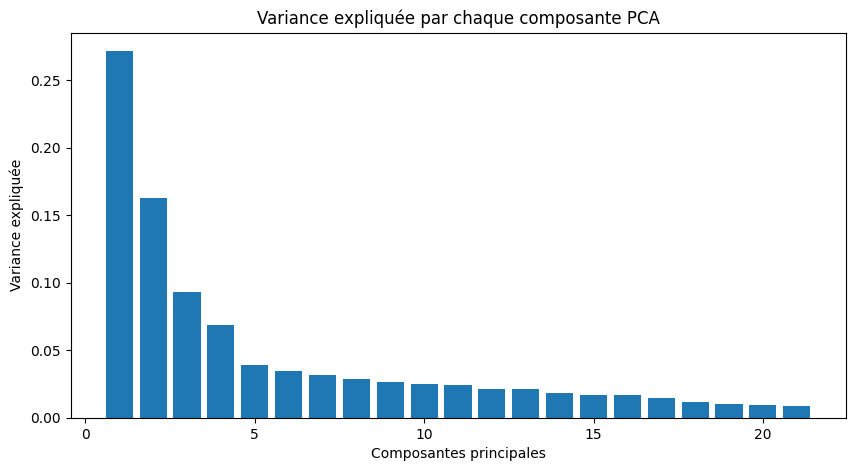

In [27]:
# ==================================================
# 24. GRAPHIQUE VARIANCE PCA
# ==================================================

plt.figure(figsize=(10,5))

plt.bar(
    range(1, len(pca_95.explained_variance_ratio_) + 1),
    pca_95.explained_variance_ratio_
)

plt.xlabel("Composantes principales")
plt.ylabel("Variance expliquée")
plt.title("Variance expliquée par chaque composante PCA")

plt.show()

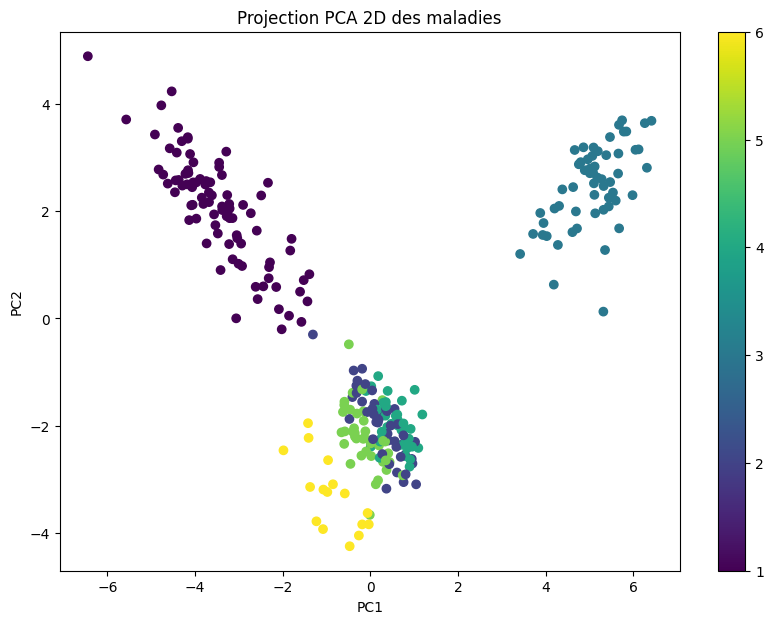

In [28]:
# ==================================================
# 25. VISUALISATION PCA 2D
# ==================================================

pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=y_train,
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection PCA 2D des maladies")

plt.colorbar(scatter)

plt.show()

In [44]:
# ==================================================
# 26. FONCTION D'ÉVALUATION
# ==================================================

def evaluer_modele(nom, modele, X_train, X_test, y_train, y_test):

    modele.fit(X_train, y_train)

    y_pred = modele.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("="*60)
    print("Modèle :", nom)
    print("Accuracy :", acc)
    print("\nClassification Report :\n")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(7,5))

    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Matrice de confusion - {nom}")
    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")

    plt.show()

    return acc

Modèle : KNN avec PCA
Accuracy : 0.918918918918919

Classification Report :

              precision    recall  f1-score   support

           1       1.00      0.96      0.98        23
           2       0.89      0.67      0.76        12
           3       1.00      0.93      0.97        15
           4       0.67      1.00      0.80        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.92        74
   macro avg       0.93      0.93      0.92        74
weighted avg       0.94      0.92      0.92        74



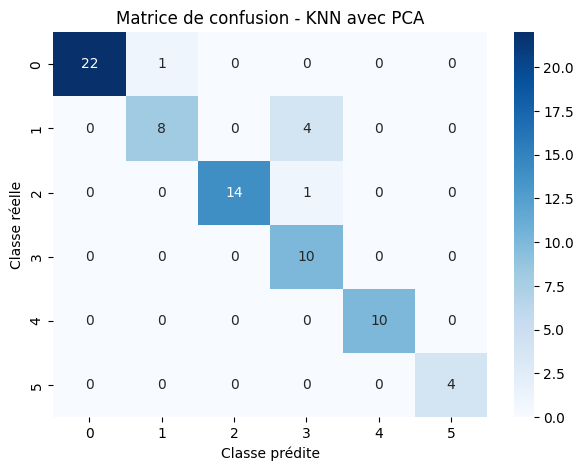

In [55]:
# ==================================================
# 27. KNN -- SELECTION DU MEILLEUR K
# ==================================================

k_range  = range(1, 21)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_pca, y_train)
    k_scores.append(knn.score(X_test_pca, y_test))

best_k   = list(k_range)[k_scores.index(max(k_scores))]
best_acc = max(k_scores)

# Graphique accuracy vs K
plt.figure(figsize=(10, 5))
plt.plot(k_range, k_scores, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--',
            label=f'Meilleur K = {best_k}')
plt.scatter([best_k], [best_acc], color='red', zorder=5, s=100)
plt.title(f"Accuracy KNN selon K  |  Meilleur K = {best_k}  (Accuracy = {best_acc:.4f})")
plt.xlabel("Nombre de voisins K")
plt.ylabel("Accuracy (test)")
plt.xticks(list(k_range))
plt.legend()
plt.grid(alpha=0.4)
plt.show()

print(f"Meilleur K retenu : K = {best_k}  ->  Accuracy = {best_acc:.4f}")

# Entrainement final avec le meilleur K
knn_model = KNeighborsClassifier(n_neighbors=best_k)

acc_knn = evaluer_modele(
    f"KNN (K={best_k}) avec PCA",
    knn_model,
    X_train_pca,
    X_test_pca,
    y_train,
    y_test
)


Modèle : SVM avec PCA
Accuracy : 0.972972972972973

Classification Report :

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      1.00      1.00        15
           4       0.83      1.00      0.91        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.97        74
   macro avg       0.97      0.97      0.97        74
weighted avg       0.98      0.97      0.97        74



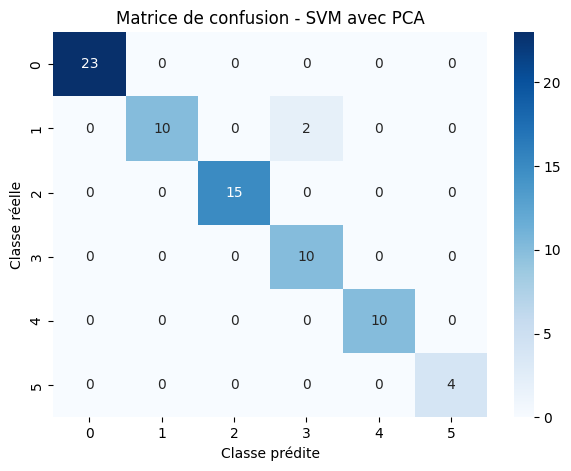

In [45]:
# ==================================================
# 27. SVM AVEC PCA
# ==================================================

svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

acc_svm = evaluer_modele(
    "SVM avec PCA",
    svm_model,
    X_train_pca,
    X_test_pca,
    y_train,
    y_test
)

In [ ]:
# ==================================================
# ARBRE DE DECISION AVEC PCA
# ==================================================

# Selection automatique de la profondeur optimale
depth_range  = range(2, 16)
depth_scores = []

for d in depth_range:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_pca, y_train)
    depth_scores.append(dt.score(X_test_pca, y_test))

best_depth = list(depth_range)[depth_scores.index(max(depth_scores))]
print(f"Meilleure profondeur : {best_depth}  ->  Accuracy = {max(depth_scores):.4f}")

# Graphique accuracy vs profondeur
plt.figure(figsize=(9, 4))
plt.plot(list(depth_range), depth_scores, marker='o', color='darkorange', linewidth=2)
plt.axvline(x=best_depth, color='red', linestyle='--',
            label=f'Meilleure profondeur = {best_depth}')
plt.scatter([best_depth], [max(depth_scores)], color='red', zorder=5, s=100)
plt.title(f"Accuracy selon la profondeur max  |  Meilleur = {best_depth}")
plt.xlabel("Profondeur max")
plt.ylabel("Accuracy (test)")
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout()
plt.show()

# Entrainement final
dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_model.fit(X_train_pca, y_train)
y_pred_dt = dt_model.predict(X_test_pca)

acc_dt = accuracy_score(y_test, y_pred_dt)

print("=" * 60)
print("Modele : Arbre de Decision")
print(f"Accuracy : {acc_dt:.4f}")
print()
print("Classification Report :")
print(classification_report(y_test, y_pred_dt))

# Matrice de confusion
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_dt),
    annot=True, fmt="d", cmap="Oranges"
)
plt.title(f"Matrice de confusion - Arbre de Decision (depth={best_depth})")
plt.xlabel("Classe predite")
plt.ylabel("Classe reelle")
plt.tight_layout()
plt.show()

# Visualisation de l'arbre (profondeur limitee a 3 pour la lisibilite)
pca_cols = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]
classes  = [str(c) for c in sorted(y_train.unique())]

plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=pca_cols,
    class_names=classes,
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title(f"Visualisation Arbre de Decision (profondeur affichee = 3 / reelle = {best_depth})")
plt.tight_layout()
plt.show()

# Importance des composantes PCA
importances = dt_model.feature_importances_
top_n  = min(10, len(importances))
idx    = importances.argsort()[::-1][:top_n]

plt.figure(figsize=(9, 4))
plt.bar([pca_cols[i] for i in idx], importances[idx], color='darkorange')
plt.title("Top composantes PCA - Importance Arbre de Decision")
plt.xlabel("Composante PCA")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


Modèle : Random Forest avec PCA
Accuracy : 0.9324324324324325

Classification Report :

              precision    recall  f1-score   support

           1       0.96      1.00      0.98        23
           2       0.90      0.75      0.82        12
           3       1.00      0.93      0.97        15
           4       0.75      0.90      0.82        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.93        74
   macro avg       0.93      0.93      0.93        74
weighted avg       0.94      0.93      0.93        74



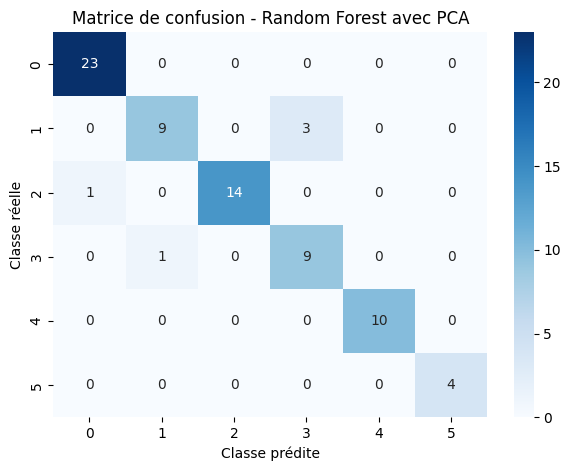

In [46]:
# ==================================================
# 28. RANDOM FOREST AVEC PCA
# ==================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

acc_rf = evaluer_modele(
    "Random Forest avec PCA",
    rf_model,
    X_train_pca,
    X_test_pca,
    y_train,
    y_test
)

Modèle : AdaBoost avec PCA
Accuracy : 0.6756756756756757

Classification Report :



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.33      1.00      0.50        12
           3       1.00      1.00      1.00        15
           4       0.00      0.00      0.00        10
           5       0.00      0.00      0.00        10
           6       0.00      0.00      0.00         4

    accuracy                           0.68        74
   macro avg       0.39      0.50      0.42        74
weighted avg       0.57      0.68      0.59        74



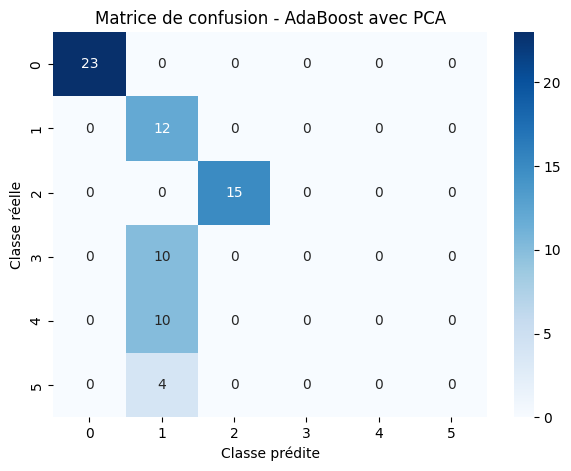

In [47]:
# ==================================================
# 29. ADABOOST AVEC PCA
# ==================================================

ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

acc_ada = evaluer_modele(
    "AdaBoost avec PCA",
    ada_model,
    X_train_pca,
    X_test_pca,
    y_train,
    y_test
)

Modèle : XGBoost avec PCA
Accuracy : 0.9054054054054054

Classification Report :

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.91      0.83      0.87        12
           2       1.00      0.93      0.97        15
           3       0.64      0.90      0.75        10
           4       0.89      0.80      0.84        10
           5       1.00      0.75      0.86         4

    accuracy                           0.91        74
   macro avg       0.91      0.87      0.88        74
weighted avg       0.92      0.91      0.91        74



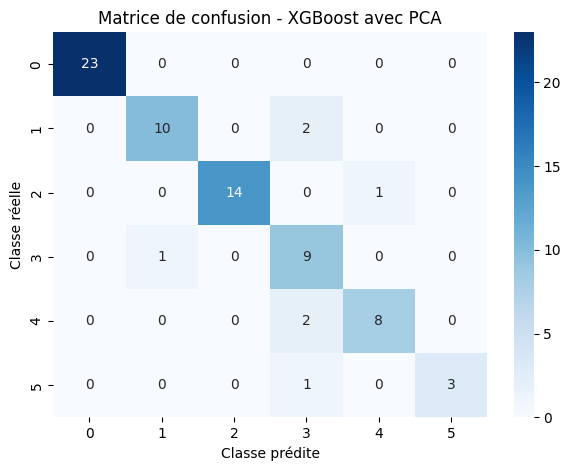

In [48]:
# ==================================================
# 30. XGBOOST AVEC PCA
# ==================================================

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss"
)

acc_xgb = evaluer_modele(
    "XGBoost avec PCA",
    xgb_model,
    X_train_pca,
    X_test_pca,
    y_train_xgb,
    y_test_xgb
)

Modèle : Régression Polynomiale
Accuracy : 0.9594594594594594

Classification Report :

              precision    recall  f1-score   support

           1       0.96      1.00      0.98        23
           2       1.00      0.83      0.91        12
           3       1.00      0.93      0.97        15
           4       0.83      1.00      0.91        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.97      0.96      0.96        74
weighted avg       0.96      0.96      0.96        74



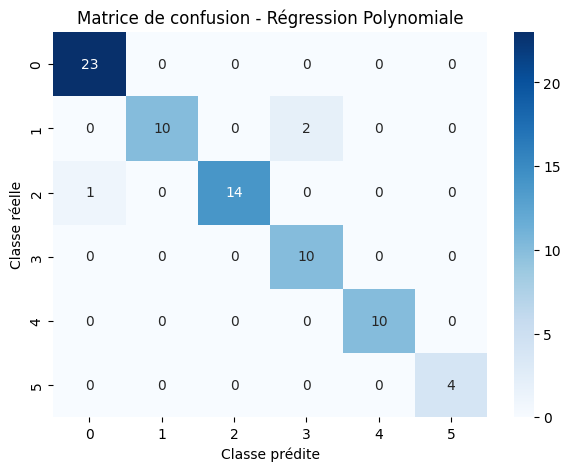

In [ ]:
# ==================================================
# 32. RÉGRESSION POLYNOMIALE
# ==================================================

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=5000))
])

acc_poly = evaluer_modele(
    "LogisticRegression",
    poly_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

In [ ]:
# ==================================================
# NAIVE BAYES AVEC PCA
# ==================================================

nb_model = GaussianNB()

nb_model.fit(X_train_pca, y_train)
y_pred_nb = nb_model.predict(X_test_pca)

acc_nb = accuracy_score(y_test, y_pred_nb)

print("=" * 60)
print("Modele : Naive Bayes")
print(f"Accuracy : {acc_nb:.4f}")
print()
print("Classification Report :")
print(classification_report(y_test, y_pred_nb))

# Matrice de confusion
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_nb),
    annot=True, fmt="d", cmap="Purples"
)
plt.title("Matrice de confusion - Naive Bayes")
plt.xlabel("Classe predite")
plt.ylabel("Classe reelle")
plt.tight_layout()
plt.show()

# Comparaison probabilites par classe
proba = nb_model.predict_proba(X_test_pca)
proba_mean = proba.mean(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(range(len(proba_mean)), proba_mean, color="mediumpurple")
plt.xticks(range(len(proba_mean)),
           [f"Classe {i+1}" for i in range(len(proba_mean))],
           rotation=45)
plt.title("Probabilite moyenne predite par classe - Naive Bayes")
plt.ylabel("Probabilite moyenne")
plt.tight_layout()
plt.show()


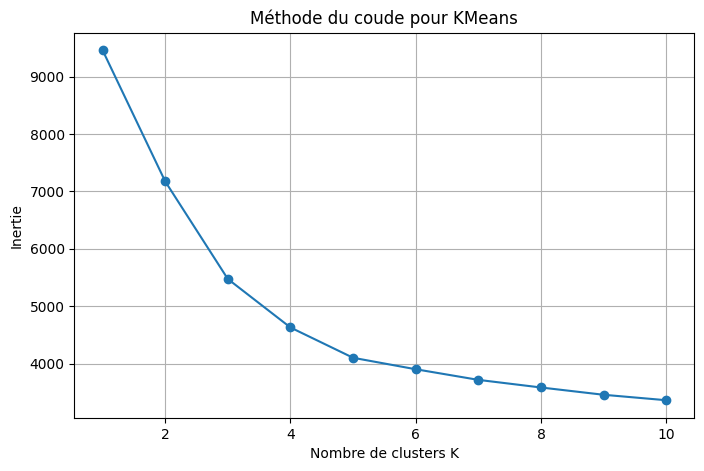

In [57]:
# ==================================================
# SELECTION DU NOMBRE OPTIMAL DE CLUSTERS (KMeans)
# Methode du Coude + Silhouette Score
# ==================================================

from sklearn.metrics import silhouette_score as sil_fn

inertia    = []
sil_scores = []
K_range    = range(2, 11)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_pca)
    inertia.append(km.inertia_)
    sil_scores.append(sil_fn(X_train_pca, labels))

best_k_km = list(K_range)[sil_scores.index(max(sil_scores))]
best_sil  = max(sil_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_range), inertia, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=best_k_km, color='red', linestyle='--',
                label=f'K recommande = {best_k_km}')
axes[0].set_title("Methode du Coude (Elbow)")
axes[0].set_xlabel("Nombre de clusters K")
axes[0].set_ylabel("Inertie")
axes[0].legend(); axes[0].grid(alpha=0.4)

# Silhouette
axes[1].plot(list(K_range), sil_scores, marker='s', color='darkorange', linewidth=2)
axes[1].axvline(x=best_k_km, color='red', linestyle='--',
                label=f'K recommande = {best_k_km}')
axes[1].scatter([best_k_km], [best_sil], color='red', zorder=5, s=100)
axes[1].set_title("Silhouette Score par K")
axes[1].set_xlabel("Nombre de clusters K")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle(
    f"Nombre optimal de clusters : K = {best_k_km}  "
    f"(Silhouette = {best_sil:.4f})",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"Nombre de clusters recommande : K = {best_k_km}  "
      f"-> Silhouette Score = {best_sil:.4f}")


In [56]:
# ==================================================
# 32. KMEANS AVEC LE MEILLEUR K (automatique)
# ==================================================

kmeans_model = KMeans(
    n_clusters=best_k_km,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(X_train_pca)

sil_km = silhouette_score(X_train_pca, kmeans_labels)
ari_km = adjusted_rand_score(y_train, kmeans_labels)

print(f"KMeans  K = {best_k_km}")
print("Silhouette Score   :", round(sil_km, 4))
print("Adjusted Rand Score:", round(ari_km, 4))

# Visualisation 2D
pca_vis = PCA(n_components=2)
X_2d_km = pca_vis.fit_transform(X_train_pca)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    X_2d_km[:, 0], X_2d_km[:, 1],
    c=kmeans_labels, cmap="tab10", alpha=0.7
)
plt.title(f"Clusters KMeans K={best_k_km} (projection PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster")
plt.show()


Silhouette Score : 0.2503740948362436
Adjusted Rand Score : 0.6949873740291338


In [ ]:
# ==================================================
# DBSCAN AVEC PCA
# ==================================================

dbscan_model = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan_model.fit_predict(X_train_pca)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = list(dbscan_labels).count(-1)

print("Nombre de clusters détectés :", n_clusters_db)
print("Points bruit (outliers)      :", n_noise_db)

if n_clusters_db >= 2:
    mask = dbscan_labels != -1
    sil_dbscan = silhouette_score(
        X_train_pca[mask], dbscan_labels[mask]
    )
    print("Silhouette Score (sans bruit):", round(sil_dbscan, 4))
    ari_dbscan = adjusted_rand_score(y_train[mask], dbscan_labels[mask])
    print("Adjusted Rand Score          :", round(ari_dbscan,  4))
else:
    print("⚠️ Pas assez de clusters pour calculer les métriques.")

# Visualisation 2D
pca_2d_db = PCA(n_components=2)
X_2d_db   = pca_2d_db.fit_transform(X_train_pca)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    X_2d_db[:, 0], X_2d_db[:, 1],
    c=dbscan_labels, cmap="tab10", alpha=0.7
)
plt.title("Clusters DBSCAN (projection PCA 2D)\n-1 = bruit/outlier")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster (-1 = bruit)")
plt.show()


In [ ]:
# ==================================================
# COMPARAISON DES MODELES SUPERVISES
# ==================================================

resultats_df = pd.DataFrame({
    "Modele": [
        "KNN",
        "Naive Bayes",
        "SVM",
        "Arbre de Decision",
        "Random Forest",
        "AdaBoost",
        "XGBoost",
        "Regression Logistique",
    ],
    "Accuracy": [
        acc_knn,
        acc_nb,
        acc_svm,
        acc_dt,
        acc_rf,
        acc_ada,
        acc_xgb,
        acc_poly,
    ]
})

resultats_df = resultats_df.sort_values(
    by="Accuracy", ascending=False
).reset_index(drop=True)

resultats_df


,Modèle,Accuracy
0,SVM,0.972973
5,Régression Polynomiale,0.959459
4,Régression Logistique,0.959459
1,Random Forest,0.932432
3,XGBoost,0.905405
2,AdaBoost,0.675676


/tmp/ipykernel_2719/3350604060.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


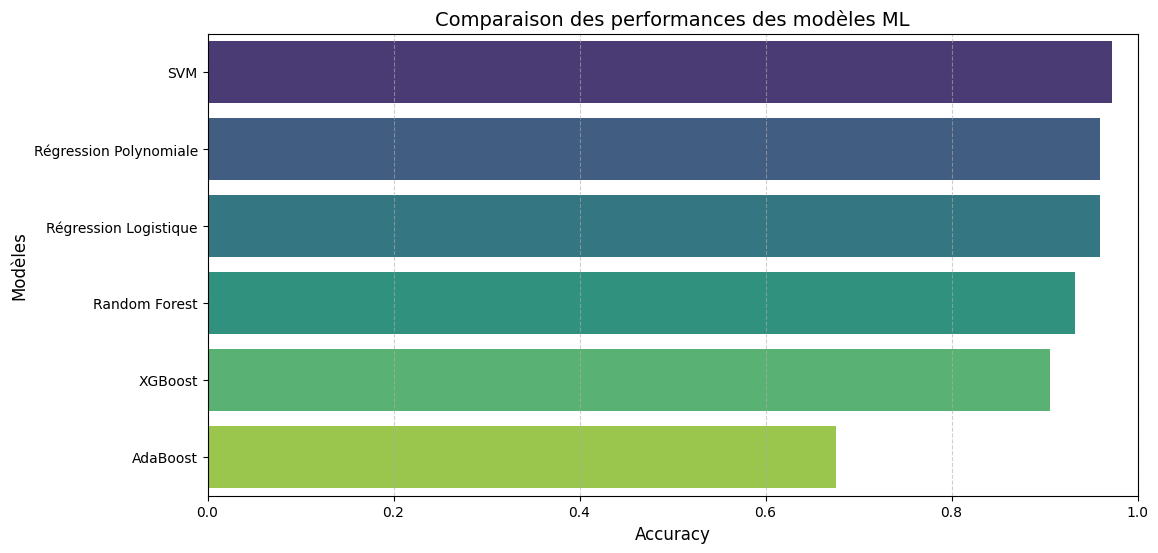

In [58]:
# ==================================================
# 34. GRAPHIQUE FINAL DES MODELES
# ==================================================

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=resultats_df,
    x="Accuracy",
    y="Modele",
    palette="viridis"
)

for i, row in resultats_df.iterrows():
    ax.text(row["Accuracy"] + 0.005, i,
            f'{row["Accuracy"]:.4f}', va='center', fontsize=10)

plt.xlim(0, 1.08)
plt.title("Comparaison des performances des modeles ML", fontsize=14)
plt.xlabel("Accuracy", fontsize=12)
plt.ylabel("Modeles", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# ==================================================
# RECOMMANDATION FINALE
# ==================================================

best_model_name = resultats_df.iloc[0]["Modele"]
best_accuracy   = resultats_df.iloc[0]["Accuracy"]

sep = "=" * 58

print(sep)
print("        RECOMMANDATION FINALE DU PROJET")
print(sep)

print()
print(">>> MODELES SUPERVISES")
print("-" * 58)
print(f"  Meilleur modele  : {best_model_name}")
print(f"  Accuracy         : {best_accuracy:.4f}  ({best_accuracy*100:.2f}%)")
print()
print("  Classement complet :")
for _, row in resultats_df.iterrows():
    bar = "#" * int(row["Accuracy"] * 30)
    print(f"    {row['Modele']:<25} {bar}  {row['Accuracy']:.4f}")

print()
print(">>> KNN -- SELECTION DU K")
print("-" * 58)
print(f"  Meilleur K retenu  : K = {best_k}")
print(f"  Accuracy obtenue   : {best_acc:.4f}  ({best_acc*100:.2f}%)")

print()
print(">>> ARBRE DE DECISION -- SELECTION DE LA PROFONDEUR")
print("-" * 58)
print(f"  Profondeur optimale : {best_depth}")
print(f"  Accuracy obtenue    : {acc_dt:.4f}  ({acc_dt*100:.2f}%)")

print()
print(">>> CLUSTERING NON SUPERVISE")
print("-" * 58)
print(f"  KMeans")
print(f"    Nombre optimal de clusters : K = {best_k_km}")
print(f"    Silhouette Score           : {sil_km:.4f}")
print(f"    Adjusted Rand Score        : {ari_km:.4f}")
print()
print("  DBSCAN")
print("    -> Detection automatique du nombre de clusters")
print("       et des outliers (points aberrants).")
print("       Complementaire a KMeans.")

print()
print(sep)
print("  CONCLUSION GENERALE")
print(sep)
print(f"  -> Meilleur modele supervise : {best_model_name}")
print(f"     Accuracy = {best_accuracy*100:.2f}%")
print(f"  -> Clustering : KMeans K={best_k_km} (Silhouette={sil_km:.4f})")
print(f"     DBSCAN pour la detection des outliers.")
print(f"  -> KNN optimal : K={best_k}")
print(f"  -> Arbre de Decision profondeur optimale : {best_depth}")
print(sep)
